In [10]:
import os, sys
sys.path.append("../")
import numpy as np
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from training.model_resnet18_lstm import ResNet18_LSTM_Attn, ResNet18_Pure, ResNet18_Attention 
from training.evaluate import evaluate_model_sliding_window
from misc.swa_fix import load_swa_model

from visualize.visualizaton import (
    plot_confusion_matrix, 
    plot_training_history, 
    plot_roc_curves, 
    plot_per_class_metrics
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### GEORGIA

In [23]:
# ── Cấu hình ────────────────────────────────────────────────
GEORGIA_ROOT  = r"E:\NCKH - 2026\ECG Project\data\raw\Georgia"
PROCESSED_DIR = r"E:\NCKH - 2026\ECG Project\data\processed_georgia\ecg_leads12_georgia"
METADATA_PATH = r"E:\NCKH - 2026\ECG Project\data\processed_georgia\georgia_metadata.xlsx"

# ── Bước 1: Tạo metadata ────────────────────────────────────
from processing.preprocess_georgia import *
df = create_metadata_from_georgia(GEORGIA_ROOT)
df = map_snomed_codes_georgia(df)
df = clean_metadata_georgia(df)
df = filter_target_labels_georgia(df)

os.makedirs(os.path.dirname(METADATA_PATH), exist_ok=True)  # ← thêm dòng này
df.to_excel(METADATA_PATH, index=False)

Tạo metadata Georgia xong: 10344 bản ghi
Mapping SNOMED codes Georgia xong
Sau làm sạch: 10344 bản ghi
Sau lọc 5 nhãn mục tiêu: 4882 bản ghi

📊 Phân phối nhãn Georgia:
   ✅ SB   :   1673 mẫu
   ✅ SR   :   1752 mẫu
   ✅ AF   :    176 mẫu
   ⚠️  SVT  :     28 mẫu  ← quá ít, chỉ dùng tham khảo
   ✅ ST   :   1253 mẫu


In [5]:
# ── Bước 2: Xử lý tín hiệu ──────────────────────────────────
from processing.feature_extraction_georgia import process_and_save_georgia_files
process_and_save_georgia_files(df, save_dir=PROCESSED_DIR)

🚀 Bắt đầu xử lý 4882 bản ghi Georgia...
   Config: FS=500, Target Length=5000, Save Dir=E:\NCKH - 2026\ECG Project\data\processed_georgia\ecg_leads12_georgia
✓ Đã xử lý 100/4882 file
✓ Đã xử lý 200/4882 file
✓ Đã xử lý 300/4882 file
✓ Đã xử lý 400/4882 file
✓ Đã xử lý 500/4882 file
✓ Đã xử lý 600/4882 file
✓ Đã xử lý 700/4882 file
✓ Đã xử lý 800/4882 file
✓ Đã xử lý 900/4882 file
✓ Đã xử lý 1000/4882 file
✓ Đã xử lý 1100/4882 file
✓ Đã xử lý 1200/4882 file
✓ Đã xử lý 1300/4882 file
✓ Đã xử lý 1400/4882 file
✓ Đã xử lý 1500/4882 file
✓ Đã xử lý 1600/4882 file
✓ Đã xử lý 1700/4882 file
✓ Đã xử lý 1800/4882 file
✓ Đã xử lý 1900/4882 file
✓ Đã xử lý 2000/4882 file
✓ Đã xử lý 2100/4882 file
✓ Đã xử lý 2200/4882 file
✓ Đã xử lý 2300/4882 file
✓ Đã xử lý 2400/4882 file
✓ Đã xử lý 2500/4882 file
✓ Đã xử lý 2600/4882 file
✓ Đã xử lý 2700/4882 file
✓ Đã xử lý 2800/4882 file
✓ Đã xử lý 2900/4882 file
✓ Đã xử lý 3000/4882 file
✓ Đã xử lý 3100/4882 file
✓ Đã xử lý 3200/4882 file
✓ Đã xử lý 3300/488

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,


In [ ]:
# ── Bước 3: Tạo test split ───────────────────────────────────
from processing.split_dataset_georgia import run_split_georgia
run_split_georgia()

In [24]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

class GeorgiaDirectDataset(Dataset):
    """Load trực tiếp từ folder .npy, không cần split files."""
    
    def __init__(self, npy_dir, df_metadata):
        """
        Args:
            npy_dir     : thư mục ecg_leads12_georgia
            df_metadata : DataFrame từ georgia_metadata.xlsx
                          (đã qua filter_target_labels_georgia)
        """
        # SNOMED → index (PHẢI khớp thứ tự train Chapman)
        self.snomed_to_idx = {
            '426177001': 0,  # SB
            '426783006': 1,  # SR
            '164890007': 2,  # AF
            '426761007': 3,  # SVT
            '427084000': 4,  # ST
        }
        self.n_classes = 5

        # Chỉ giữ các record có file .npy tồn tại thực sự
        records = []
        for _, row in df_metadata.iterrows():
            npy_path = os.path.join(npy_dir, f"{row['record_id']}.npy")
            if os.path.exists(npy_path):
                records.append({
                    'npy_path'     : npy_path,
                    'record_id'    : row['record_id'],
                    'snomed'       : row['primary_snomed'],
                    'label_short'  : row['primary_label'],
                    'label_idx'    : self.snomed_to_idx[row['primary_snomed']],
                })

        self.records = records
        print(f"✅ Dataset Georgia: {len(self.records)} mẫu hợp lệ")

        # In phân phối
        from collections import Counter
        dist = Counter(r['label_short'] for r in self.records)
        for label in ['SB', 'SR', 'AF', 'SVT', 'ST']:
            print(f"   {label}: {dist.get(label, 0)}")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r      = self.records[idx]
        signal = np.load(r['npy_path'])          # (12, 5000)

        label  = np.zeros(self.n_classes, dtype=np.float32)
        label[r['label_idx']] = 1.0

        return (
            torch.tensor(signal, dtype=torch.float32),
            torch.tensor(label,  dtype=torch.float32)
        )

In [25]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd

# ── Cấu hình ────────────────────────────────────────────────
GEORGIA_NP_DIR    = r"E:\NCKH - 2026\ECG Project\data\processed_georgia\ecg_leads12_georgia"
GEORGIA_META_PATH = r"E:\NCKH - 2026\ECG Project\data\processed_georgia\georgia_metadata.xlsx"
MODEL_PATH        = r"E:\NCKH - 2026\ECG Project\models\resnet18_lstm_mixup_swa_160125.pth"

display_names = ['SB', 'SR', 'AF', 'SVT', 'ST']

SNOMED_TO_IDX = {
    '426177001': 0,  # SB
    '426783006': 1,  # SR
    '164890007': 2,  # AF
    '426761007': 3,  # SVT
    '427084000': 4,  # ST
}

In [26]:
# ── Cell 2: Tạo loader và y_georgia ─────────────────────────
class GeorgiaDataset(Dataset):
    def __init__(self, npy_dir, df_meta):
        self.records = []
        for _, row in df_meta.iterrows():
            npy_path = os.path.join(npy_dir, f"{row['record_id']}.npy")
            if os.path.exists(npy_path):
                self.records.append({
                    'npy_path'  : npy_path,
                    'label_idx' : SNOMED_TO_IDX[str(row['primary_snomed'])],  # ← thêm str()
                })
        print(f"✅ Georgia Dataset: {len(self.records)} mẫu")
        from collections import Counter
        dist = Counter(r['label_idx'] for r in self.records)
        for name, idx in zip(display_names, range(5)):
            print(f"   {name}: {dist.get(idx, 0)}")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r      = self.records[idx]
        signal = np.load(r['npy_path']).astype(np.float32)
        label  = np.zeros(5, dtype=np.float32)
        label[r['label_idx']] = 1.0
        return torch.tensor(signal), torch.tensor(label)

df_meta        = pd.read_excel(METADATA_PATH)
georgia_dataset = GeorgiaDataset(PROCESSED_DIR, df_meta)
georgia_loader  = DataLoader(georgia_dataset, batch_size=32,
                              shuffle=False, num_workers=0)

y_georgia = np.array([
    np.eye(5)[r['label_idx']]
    for r in georgia_dataset.records
], dtype=np.float32)

print(f"y_georgia shape: {y_georgia.shape}")

✅ Georgia Dataset: 4882 mẫu
   SB: 1673
   SR: 1752
   AF: 176
   SVT: 28
   ST: 1253
y_georgia shape: (4882, 5)


In [27]:
# ── Cell 3: Load model và test ───────────────────────────────
model = ResNet18_LSTM_Attn(num_classes=len(display_names), input_channels=12)
model = load_swa_model(MODEL_PATH, model, device)
model.eval()
print("Model loaded OK")

y_pred_bin, y_pred_probs, cms, metrics = evaluate_model(
    model, georgia_loader, y_georgia, 
    device=device, 
    target_names=display_names
)

Model loaded OK
⏳ Đang thực hiện đánh giá (Standard Evaluation)...

============================== CLASSIFICATION REPORT ==============================
              precision    recall  f1-score   support

          SB       0.99      0.98      0.98      1673
          SR       0.98      0.95      0.97      1752
          AF       0.73      0.84      0.78       176
         SVT       0.33      0.36      0.34        28
          ST       0.98      0.93      0.96      1253

   micro avg       0.97      0.95      0.96      4882
   macro avg       0.80      0.81      0.81      4882
weighted avg       0.97      0.95      0.96      4882
 samples avg       0.95      0.95      0.95      4882


============================== CONFUSION MATRICES ==============================
🔹 SB:
[[3190   19]
 [  33 1640]]

🔹 SR:
[[3103   27]
 [  89 1663]]

🔹 AF:
[[4651   55]
 [  28  148]]

🔹 SVT:
[[4834   20]
 [  18   10]]

🔹 ST:
[[3610   19]
 [  84 1169]]



✅ Confusion matrices saved to E:\NCKH - 2026\ECG Project\data\processed\assets\cm1_georgia.png


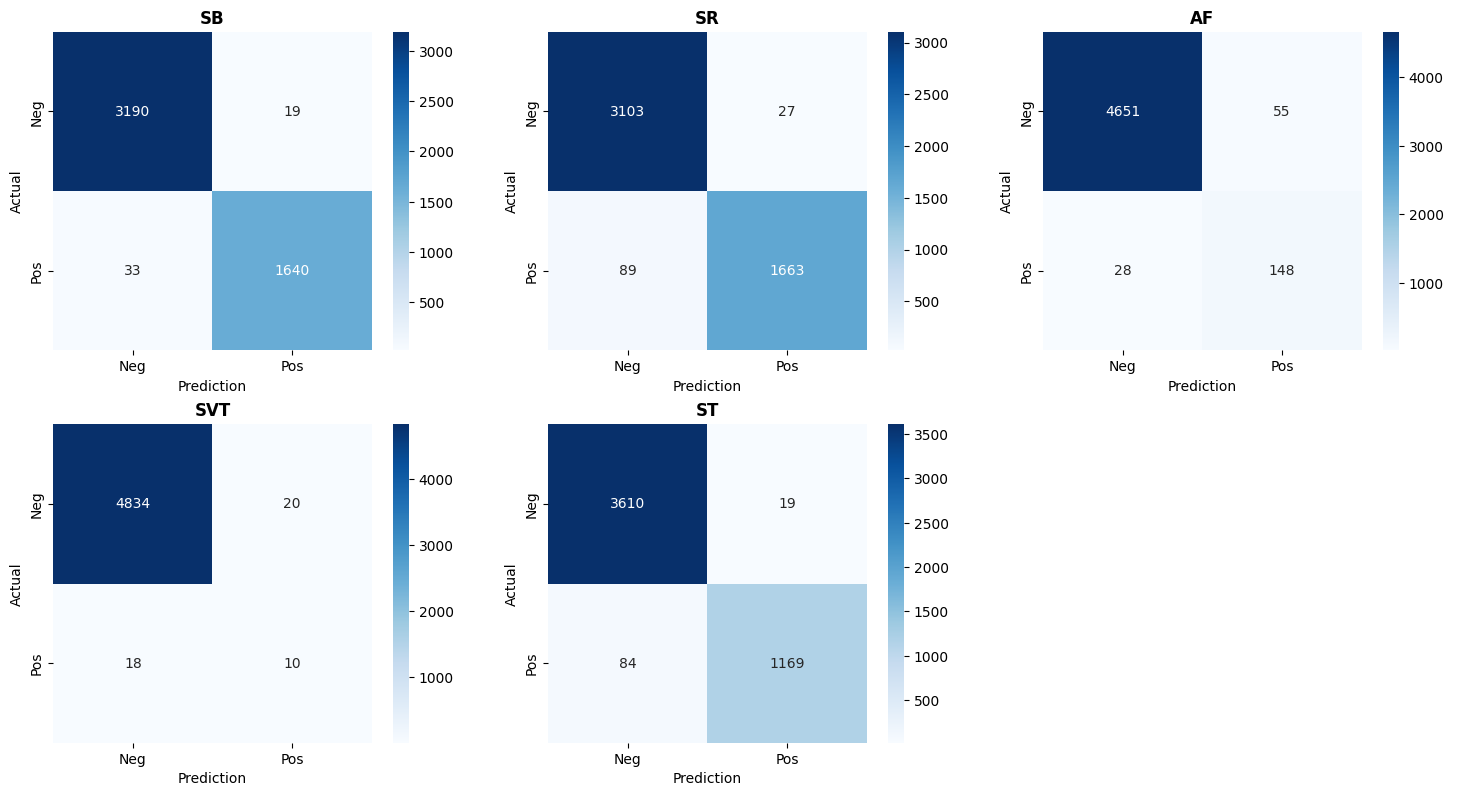

✅ ROC curves saved to E:\NCKH - 2026\ECG Project\data\processed\assets\roc1_georgia.png


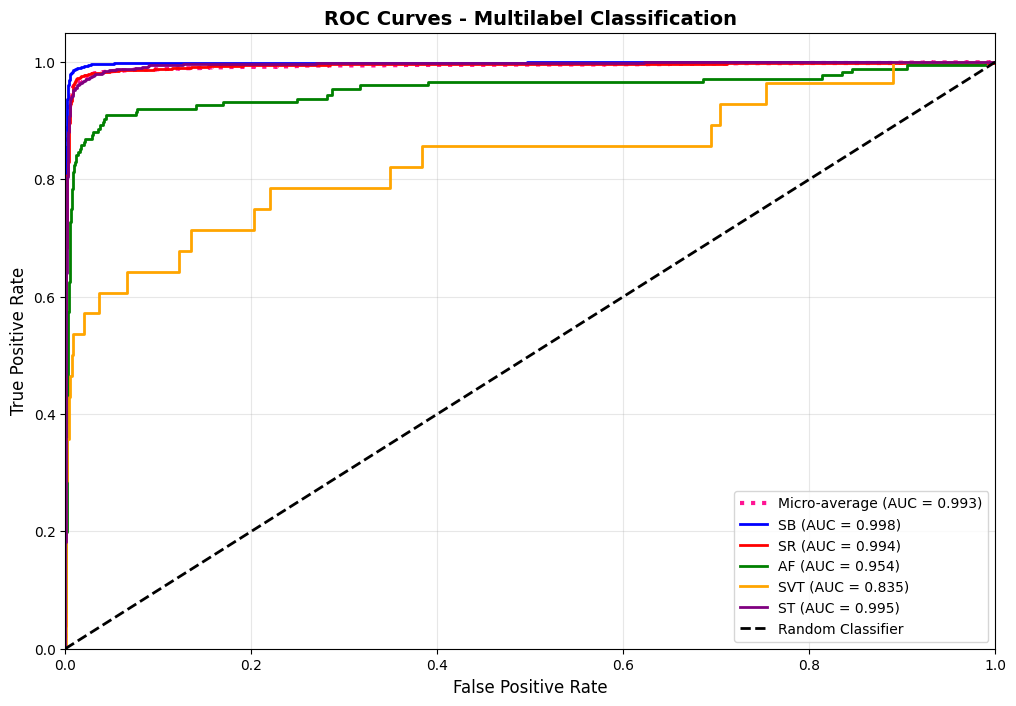

✅ Per-class metrics saved to E:\NCKH - 2026\ECG Project\data\processed\assets\metrics1_georgia.png


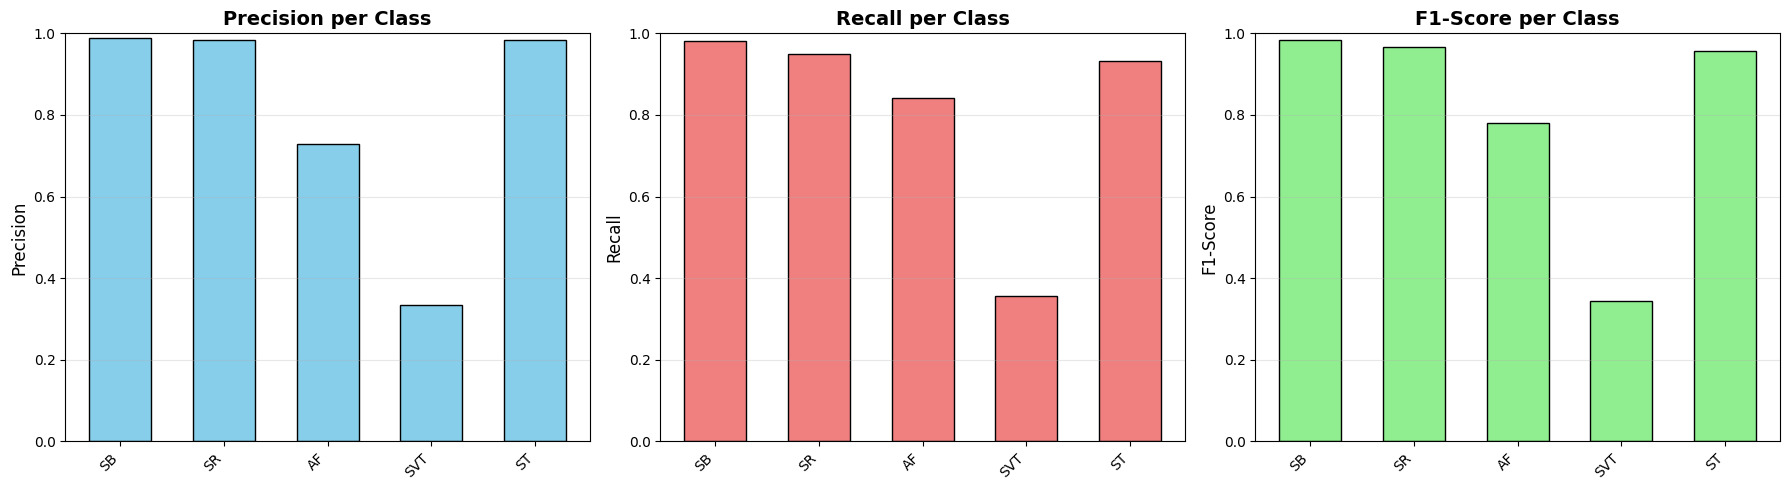

In [28]:
# 4. Visualize results
plot_confusion_matrix(y_georgia, y_pred_bin, display_names, save_path=r"E:\NCKH - 2026\ECG Project\data\processed\assets\cm1_georgia.png")
plot_roc_curves(y_georgia, y_pred_probs, display_names, save_path=r"E:\NCKH - 2026\ECG Project\data\processed\assets\roc1_georgia.png")
plot_per_class_metrics(metrics, display_names, save_path=r"E:\NCKH - 2026\ECG Project\data\processed\assets\metrics1_georgia.png")

### PTB-XL

In [29]:
# ============================================================
# TEST CROSS-DATASET: Chapman model → PTB-XL data
# Không cần split, dùng trực tiếp ecg_leads12_ptbxl
# ============================================================

# ── Đường dẫn ──
BASE          = r"E:\NCKH - 2026\ECG Project\data"
PTBXL_NPY    = os.path.join(BASE, "processed_ptbxl", "ecg_leads12_ptbxl")
METADATA_XLS = os.path.join(BASE, "processed_ptbxl", "ptbxl_metadata.xlsx")
CHAPMAN_SPLIT = os.path.join(BASE, "processed", "splits_leads12_160125")
MODEL_PATH   = r"E:\NCKH - 2026\ECG Project\models\resnet18_lstm_mixup_swa_160125.pth"

# ── Lấy thứ tự nhãn đúng từ Chapman ──
# QUAN TRỌNG: phải dùng thứ tự này, không phải thứ tự PTB-XL
CHAPMAN_TARGET_NAMES = np.load(
    os.path.join(CHAPMAN_SPLIT, "target_names.npy"), 
    allow_pickle=True
).tolist()

print("="*60)
print("📋 CHAPMAN DATASET TARGET ORDER")
print("="*60)
print(f"Target names (SNOMED codes): {CHAPMAN_TARGET_NAMES}")

# Map SNOMED → Tên dễ đọc (CHỈ để hiển thị)
SNOMED_TO_NAME = {
    '426177001': 'SB',   # Sinus Bradycardia
    '426783006': 'SR',   # Sinus Rhythm  
    '164890007': 'AF',   # Atrial Fibrillation
    '426761007': 'SVT',  # Supraventricular Tachycardia
    '427084000': 'ST'    # Sinus Tachycardia
}

# Tạo display names theo thứ tự Chapman
display_names = [SNOMED_TO_NAME.get(code, code) for code in CHAPMAN_TARGET_NAMES]
print(f"Display names: {display_names}")
print(f"Number of classes: {len(CHAPMAN_TARGET_NAMES)}")

📋 CHAPMAN DATASET TARGET ORDER
Target names (SNOMED codes): ['426177001', '426783006', '164890007', '426761007', '427084000']
Display names: ['SB', 'SR', 'AF', 'SVT', 'ST']
Number of classes: 5


In [30]:
# ── Đọc metadata PTB-XL ──
df = pd.read_excel(METADATA_XLS)
print(f"Tổng metadata: {len(df)} bản ghi")

# Chỉ giữ file đã tồn tại trong ecg_leads12_ptbxl
df["npy_path"] = df["record_id"].apply(
    lambda rid: os.path.join(PTBXL_NPY, f"{rid}.npy")
)
df = df[df["npy_path"].apply(os.path.exists)].reset_index(drop=True)
print(f"File tồn tại: {len(df)} bản ghi")

# ── Map ngược: display_name → SNOMED để tạo y ──
NAME_TO_SNOMED = {v: k for k, v in SNOMED_TO_NAME.items()}
# display_names đã theo thứ tự Chapman, tạo SNOMED codes cùng thứ tự
TARGET_COLS_ORDERED = [NAME_TO_SNOMED[name] for name in display_names]

# ── Tạo ma trận nhãn y theo thứ tự display_names (= thứ tự Chapman) ──
y_ptbxl = np.zeros((len(df), len(display_names)), dtype=np.float32)
for i, code in enumerate(TARGET_COLS_ORDERED):
    y_ptbxl[:, i] = (df["diagnosis_codes"].astype(str) == str(code)).astype(float)

# Kiểm tra phân phối
print("\nPhân phối nhãn PTB-XL (theo thứ tự Chapman):")
for i, name in enumerate(display_names):
    n = int(y_ptbxl[:, i].sum())
    flag = "✅" if n >= 30 else ("⚠️ " if n >= 5 else "❌")
    note = "  ← quá ít, chỉ tham khảo" if n < 30 else ""
    print(f"  {flag} {name}: {n} mẫu{note}")

Tổng metadata: 13640 bản ghi
File tồn tại: 13640 bản ghi

Phân phối nhãn PTB-XL (theo thứ tự Chapman):
  ✅ SB: 498 mẫu
  ✅ SR: 12431 mẫu
  ✅ AF: 31 mẫu
  ⚠️  SVT: 10 mẫu  ← quá ít, chỉ tham khảo
  ✅ ST: 670 mẫu


In [31]:
# ── Dataset & DataLoader ──
from training.dataset_loader import ECGDataset

X_ptbxl = df["npy_path"].values

ptbxl_dataset = ECGDataset(X_ptbxl, y_ptbxl, augment=False)
ptbxl_loader  = DataLoader(ptbxl_dataset, batch_size=64,
                            shuffle=False, num_workers=0)

print(f"PTB-XL DataLoader: {len(ptbxl_dataset)} mẫu, "
      f"{len(ptbxl_loader)} batch")

PTB-XL DataLoader: 13640 mẫu, 214 batch


In [32]:
# ── Load model Chapman ──
# ── Cell 3: Load model và test ───────────────────────────────
model = ResNet18_LSTM_Attn(num_classes=len(display_names), input_channels=12)
model = load_swa_model(MODEL_PATH, model, device)
model.eval()
print("Model loaded OK")

y_pred_bin, y_pred_probs, cms, metrics = evaluate_model(
    model, ptbxl_loader, y_ptbxl, 
    device=device, 
    target_names=display_names
)

Model loaded OK
⏳ Đang thực hiện đánh giá (Standard Evaluation)...

============================== CLASSIFICATION REPORT ==============================
              precision    recall  f1-score   support

          SB       0.20      0.96      0.33       498
          SR       1.00      0.78      0.87     12431
          AF       0.29      0.97      0.44        31
         SVT       0.50      0.30      0.38        10
          ST       0.83      0.97      0.89       670

   micro avg       0.83      0.79      0.81     13640
   macro avg       0.56      0.79      0.58     13640
weighted avg       0.96      0.79      0.85     13640
 samples avg       0.79      0.79      0.79     13640


============================== CONFUSION MATRICES ==============================
🔹 SB:
[[11190  1952]
 [   20   478]]

🔹 SR:
[[1193   16]
 [2756 9675]]

🔹 AF:
[[13534    75]
 [    1    30]]

🔹 SVT:
[[13627     3]
 [    7     3]]

🔹 ST:
[[12840   130]
 [   23   647]]



✅ Confusion matrices saved to E:\NCKH - 2026\ECG Project\data\processed\assets\cm1_ptbxl.png


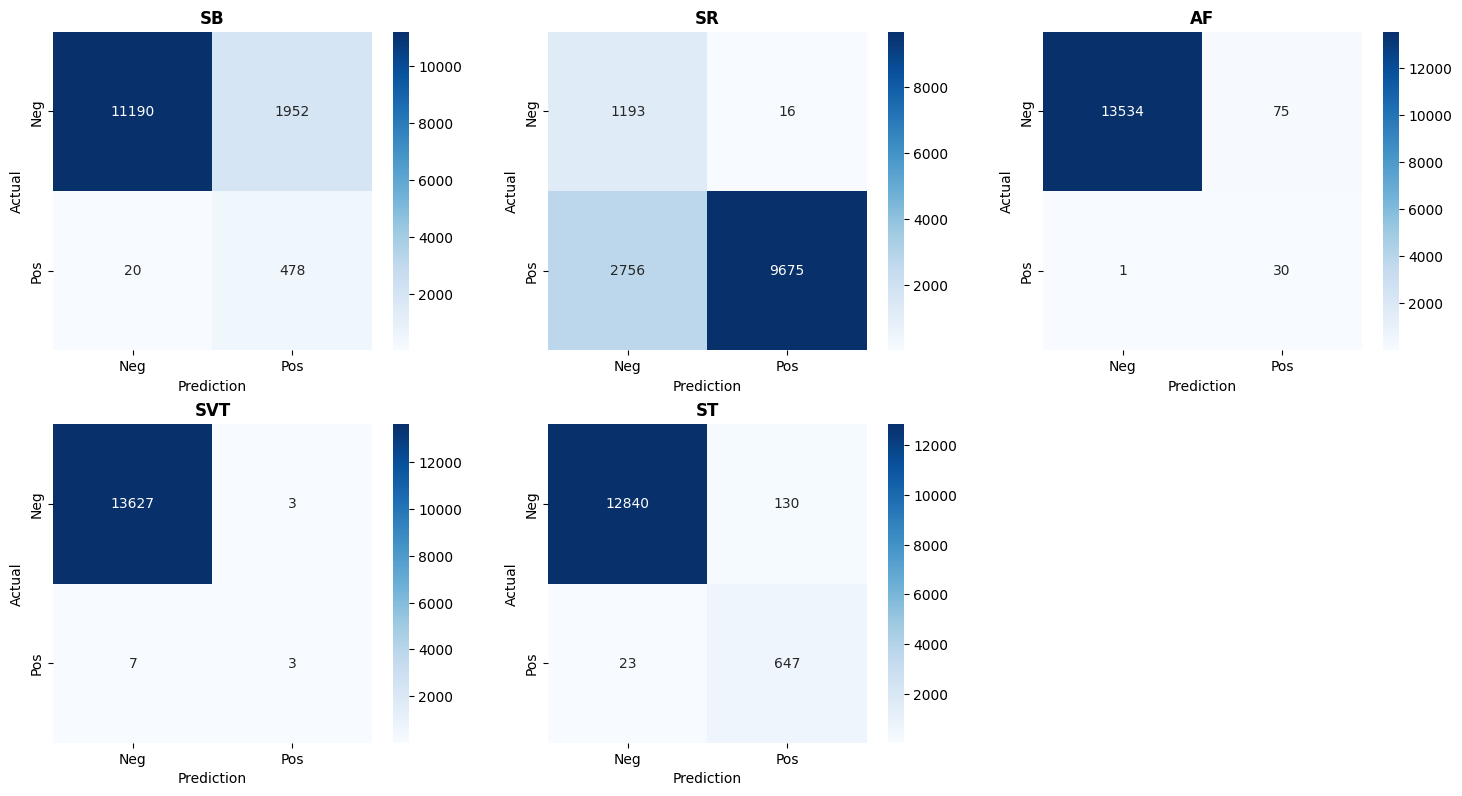

✅ ROC curves saved to E:\NCKH - 2026\ECG Project\data\processed\assets\roc1_ptbxl.png


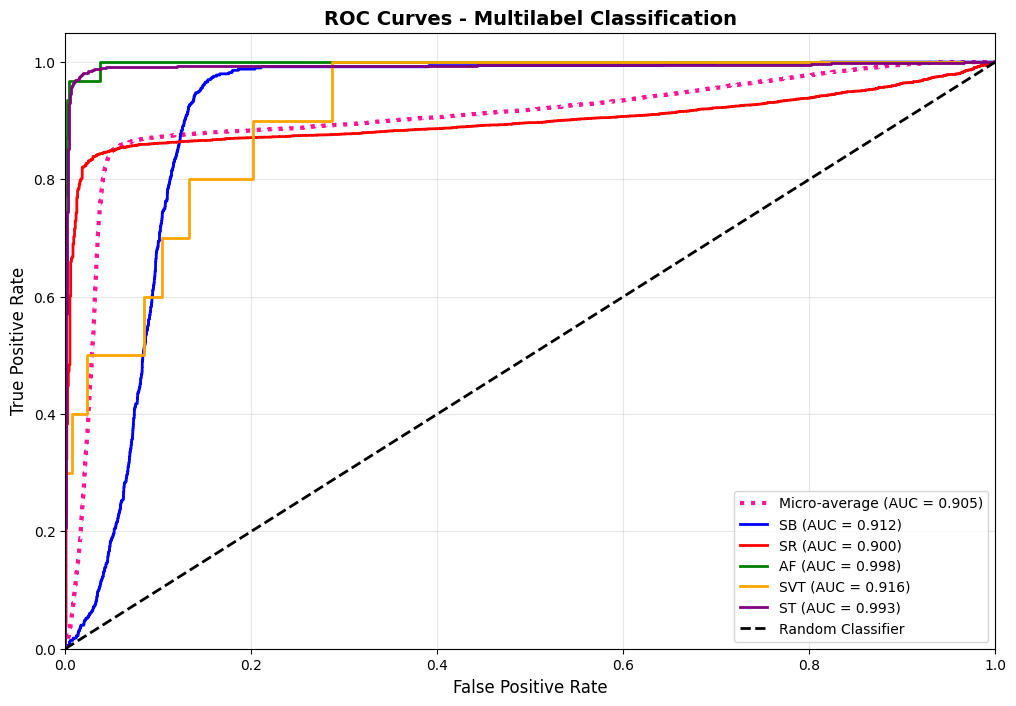

✅ Per-class metrics saved to E:\NCKH - 2026\ECG Project\data\processed\assets\metrics1_ptbxl.png


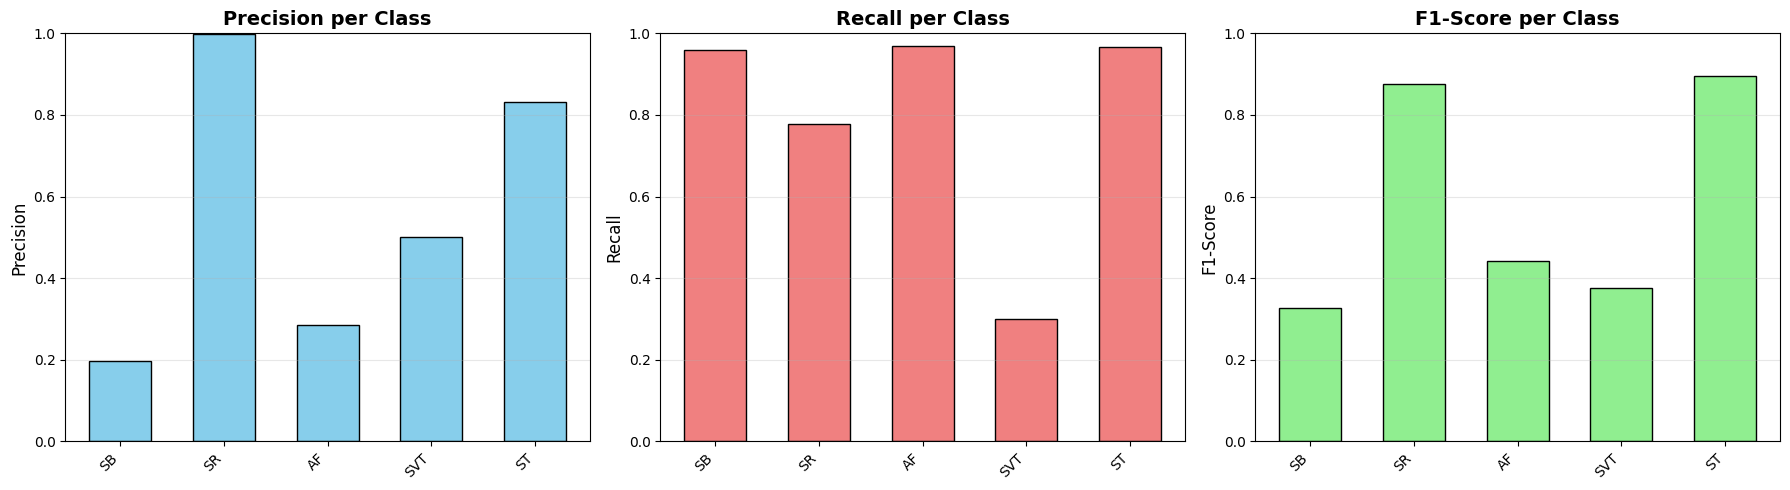

In [33]:
# 4. Visualize results
plot_confusion_matrix(y_ptbxl, y_pred_bin, display_names, save_path=r"E:\NCKH - 2026\ECG Project\data\processed\assets\cm1_ptbxl.png")
plot_roc_curves(y_ptbxl, y_pred_probs, display_names, save_path=r"E:\NCKH - 2026\ECG Project\data\processed\assets\roc1_ptbxl.png")
plot_per_class_metrics(metrics, display_names, save_path=r"E:\NCKH - 2026\ECG Project\data\processed\assets\metrics1_ptbxl.png")